## **Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from portfolio_forecast.forecast import (nonparametric_monte_carlo, parametric_monte_carlo,
                                         regime_switching_monte_carlo)
from portfolio_forecast.plotting import plot_path_comparison, plot_simulated_paths
from portfolio_forecast.performance import statistical_report
from portfolio_forecast.utils import next_trading_dates
import yfinance as yf

## **Obtaining example data**

In [2]:
# Ten years of daily AAPL bars from Yahoo Finance, adjusted for splits and dividends
df_full = yf.download('AAPL', period='10y', auto_adjust=True, progress=False)

### **Reformating the example data as a dataframe with a single column**

Index: Date / Datetime

Column: Portfolio Value / Prices

In [3]:
# Taking closing prices as a single-column dataframe; dropna removes a trailing
# row with no close, which Yahoo can return while a session is incomplete
prices = df_full['Close'].dropna()
prices

Ticker,AAPL
Date,
2016-09-19,25.974117
2016-09-20,25.971825
2016-09-21,25.967257
2016-09-22,26.211952
2016-09-23,25.775152
...,...
2026-09-11,332.269989
2026-09-14,333.079987
2026-09-15,331.339996


## **Example Simulations**

In [4]:
# Dates for the plots: the last historical close (each path's starting value)
# followed by the next 100 trading days, matching sim_length=100 below
sim_dates = prices.index[-1:].append(next_trading_dates(prices.index, 100))

### **Example 1: Non-parametric Monte Carlo**

In [5]:
# A seed (an int or a seeded Generator) makes the paths reproducible
# Resampling historical returns with replacement
sims_nonparametric = nonparametric_monte_carlo(prices, sim_length=100, n_sims=1000,
                                               random_state=np.random.default_rng(42))

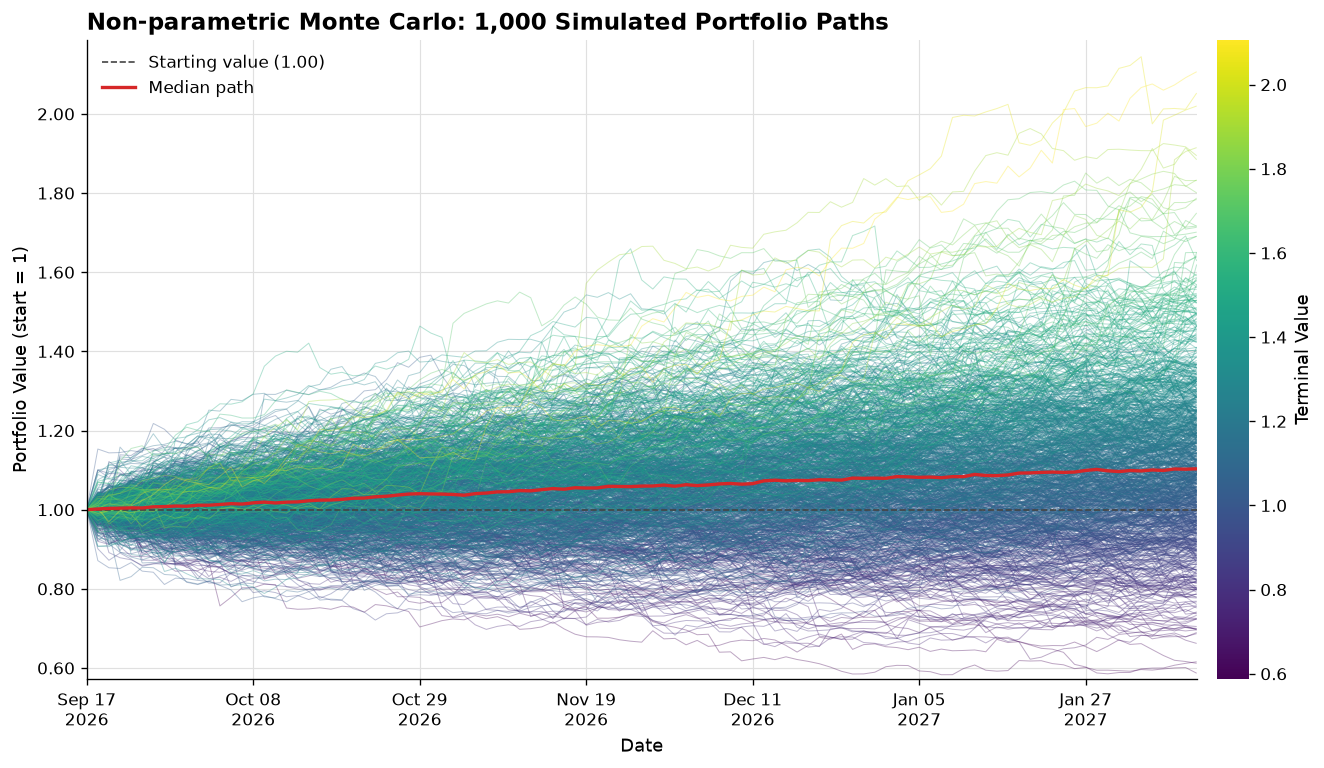

In [6]:
fig, ax = plot_simulated_paths(sims_nonparametric, method='Non-parametric Monte Carlo', dates=sim_dates)
plt.show()

### **Example 2: Parametric Monte Carlo**

In [7]:
# distribution=None fits normal, t, and Johnson SU and uses the lowest AIC
sims_parametric = parametric_monte_carlo(prices, distribution=None, sim_length=100, n_sims=1000,
                                         random_state=np.random.default_rng(42))

      norm AIC: -12,955.96
         t AIC: -13,474.97
 johnsonsu AIC: -13,480.71
Selected: johnsonsu


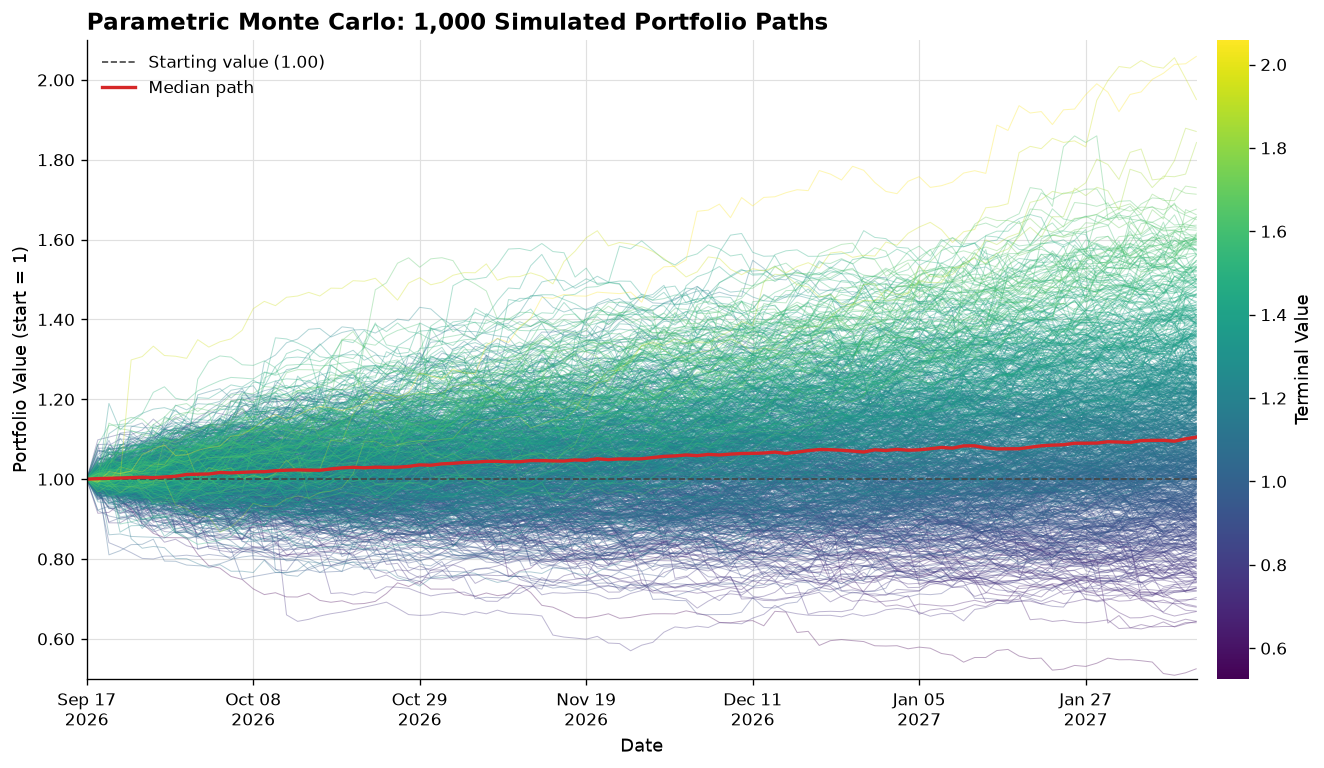

In [8]:
fig, ax = plot_simulated_paths(sims_parametric, method='Parametric Monte Carlo', dates=sim_dates)
plt.show()

### **Example 3: Regime-Switching Monte Carlo**

In [9]:
# n_regimes=None fits 1, 2, and 3 regimes and uses the lowest BIC;
# bootstrap=True would resample each regime's historical returns instead of drawing from a normal
sims_regime = regime_switching_monte_carlo(prices, n_regimes=None, bootstrap=False, sim_length=100,
                                           n_sims=1000, random_state=np.random.default_rng(42))

1 regime(s) BIC: -12,948.43


2 regime(s) BIC: -13,539.01


3 regime(s) BIC: -13,582.92
Selected: 3 regime(s)
Regime 0: mean +0.1757%, vol 1.1078%, expected duration 21.2 periods
Regime 1: mean +0.0259%, vol 2.2801%, expected duration 11.3 periods
Regime 2: mean -0.6063%, vol 5.7449%, expected duration 8.3 periods


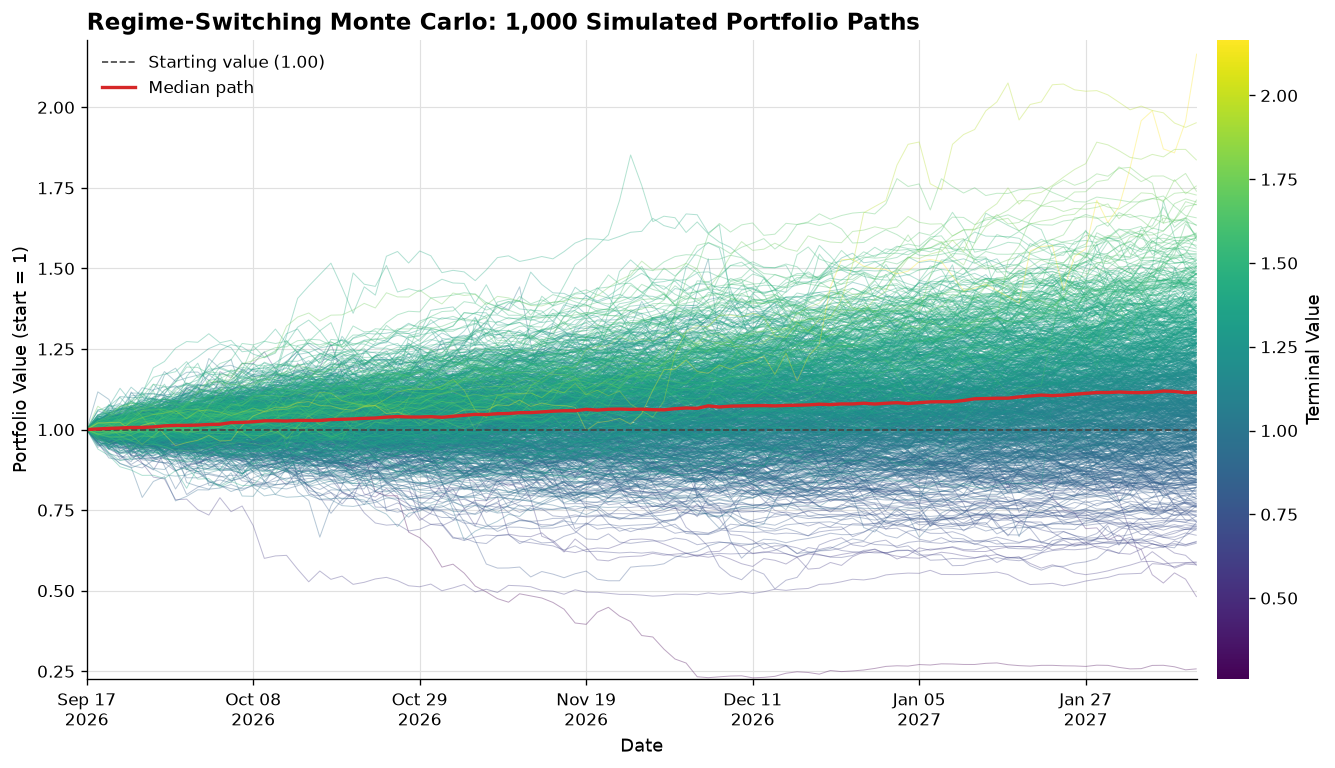

In [10]:
fig, ax = plot_simulated_paths(sims_regime, method='Regime-Switching Monte Carlo', dates=sim_dates)
plt.show()

### **Comparison: All Methods Side by Side**

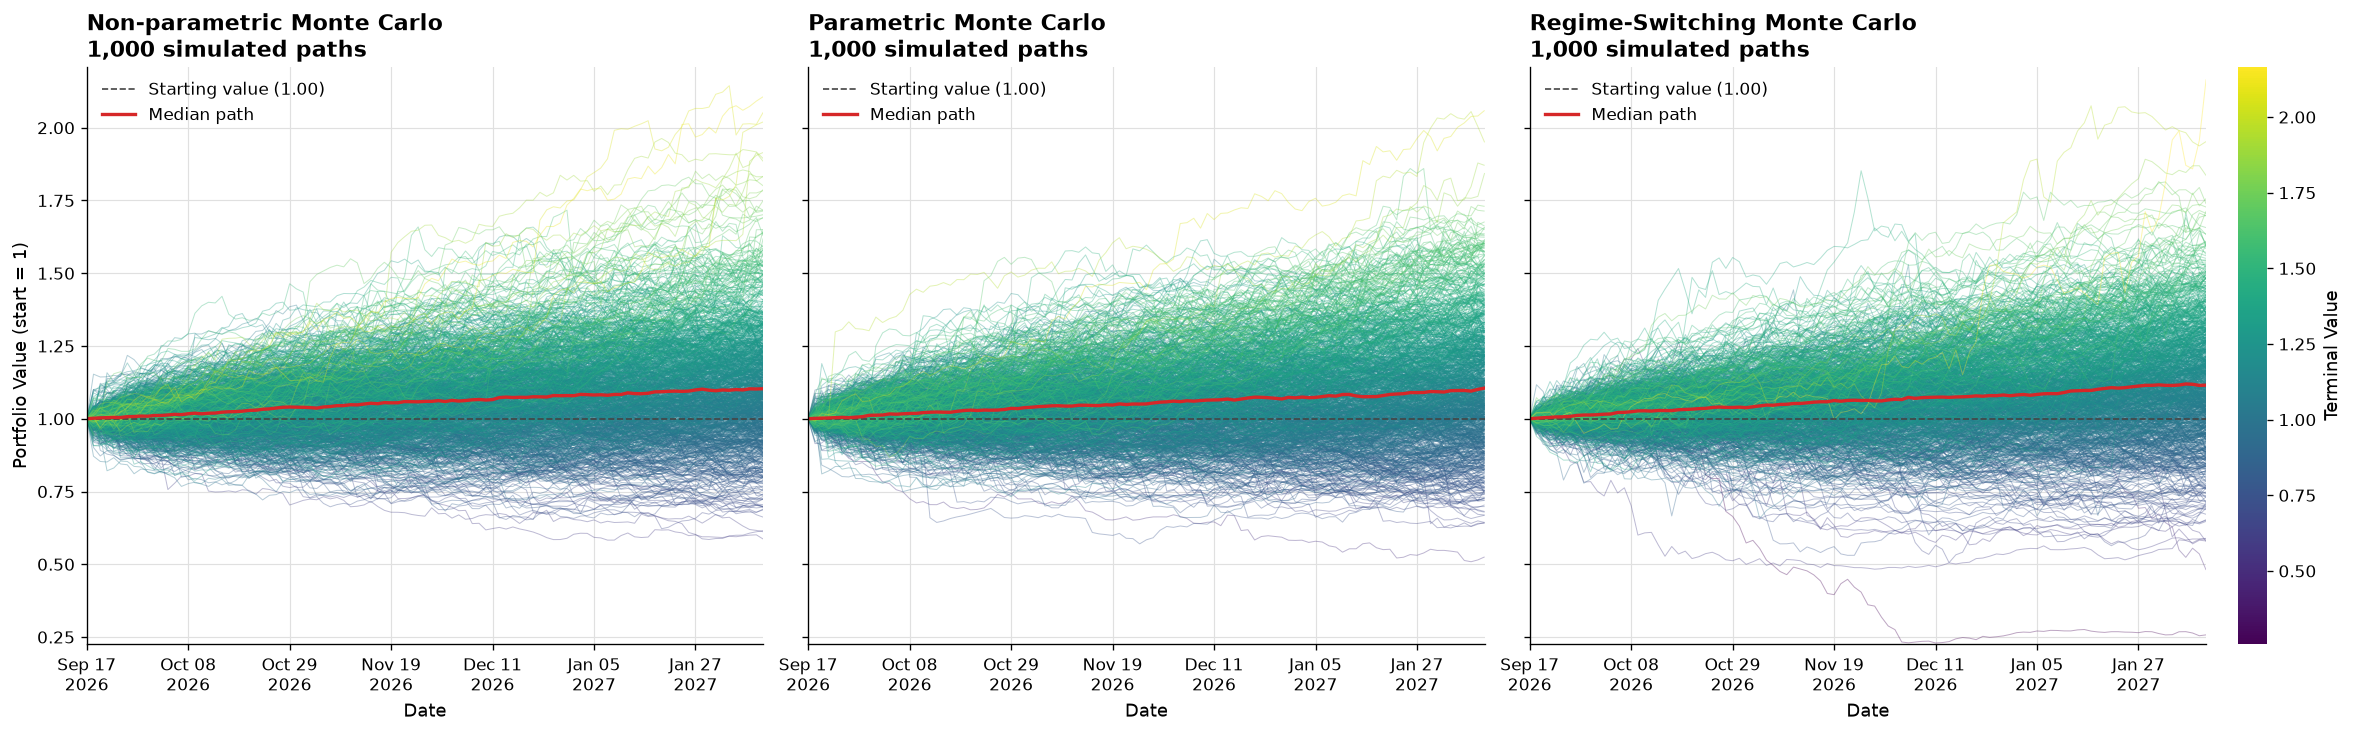

In [11]:
# All three methods side by side, on a shared y-axis and color scale
fig, axes = plot_path_comparison({
    'Non-parametric Monte Carlo': sims_nonparametric,
    'Parametric Monte Carlo': sims_parametric,
    'Regime-Switching Monte Carlo': sims_regime,
}, dates=sim_dates)
plt.show()

### **Statistical Reports**

In [12]:
# Each metric's median and 95% interval across the simulated paths, per method
for method, sims in {
    'Non-parametric Monte Carlo': sims_nonparametric,
    'Parametric Monte Carlo': sims_parametric,
    'Regime-Switching Monte Carlo': sims_regime,
}.items():
    print(f'{method} Report')
    report = statistical_report(sims, interval='1 day', confidence=0.95, display=True)

Non-parametric Monte Carlo Report

                     SIMULATED PORTFOLIO STATISTICAL REPORT                     
--------------------------------------------------------------------------------
  Simulated Paths      : 1,000
  Horizon              :   100 periods  (0.40 years)
                                    RETURNS                                     
--------------------------------------------------------------------------------
                               Mean       Median                   95% interval
--------------------------------------------------------------------------------
  Final Bankroll       :       1.13         1.10                   [0.77, 1.59]
  Total Return         :     12.73%       10.33%              [-23.12%, 59.09%]
  CAGR                 :     44.43%       28.10%             [-48.45%, 222.21%]
                                      RISK                                      
---------------------------------------------------------------------------